# E‑Commerce Customer Analytics
### Customer Behaviour, Revenue Trends & Risk Insights

**Author:** Shalyne Murage

This project analyzes simulated e‑commerce transaction data to uncover:
- Revenue trends
- Customer value
- Customer segmentation using RFM
- Payment behaviour and risk

Dataset includes:
- 5,000 customers
- 200 products
- 50,000 orders
- Payment transaction records


## 1. Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Load Datasets

The dataset consists of four tables representing an e-commerce platform:

- Customers (5,000 records)
- Products (200 products)
- Orders (50,000 transactions)
- Payments (transaction outcomes)

These tables are merged to create a unified dataset for customer and revenue analysis.

In [28]:
customers = pd.read_csv('Data/customers.csv')
products = pd.read_csv('Data/products.csv')
orders = pd.read_csv('Data/orders.csv')
payments = pd.read_csv('Data/payments.csv')

customers.head()

,customer_id,gender,age,region,signup_date
0,1,Male,64,Eldoret,19/03/2022
1,2,Female,64,Nakuru,18/06/2023
2,3,Male,21,Mombasa,18/04/2022
3,4,Male,24,Eldoret,03/02/2024
4,5,Male,62,Nakuru,15/01/2022


## 3. Data Inspection

In [29]:
print('Customers:', customers.shape)
print('Products:', products.shape)
print('Orders:', orders.shape)
print('Payments:', payments.shape)

Customers: (5000, 5)
Products: (200, 3)
Orders: (50000, 5)
Payments: (50000, 3)


## 4. Merge Datasets

In [30]:
df = orders.merge(products, on='product_id')
df = df.merge(customers, on='customer_id')
df = df.merge(payments, on='order_id')

df.head()

,order_id,customer_id,product_id,quantity,order_date,category,price,gender,age,region,signup_date,payment_method,payment_status
0,1,2706,90,4,29/09/2023,Fashion,37107.78,Female,49,Nairobi,07/08/2024,M-Pesa,Refunded
1,2,2484,18,4,11/09/2024,Health,11596.53,Female,36,Kisumu,02/08/2023,Cash on Delivery,Completed
2,3,4801,117,4,16/04/2023,Fashion,38161.14,Male,54,Nairobi,10/02/2024,Cash on Delivery,Completed
3,4,4830,71,2,18/03/2024,Fashion,39642.03,Male,61,Eldoret,07/02/2024,M-Pesa,Completed
4,5,3780,66,2,31/12/2023,Sports,47358.62,Female,57,Eldoret,03/07/2022,Cash on Delivery,Completed


## 5. Feature Engineering

Create revenue variable and convert dates.

In [31]:
df['revenue'] = df['price'] * df['quantity']
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['month'] = df['order_date'].dt.to_period('M')

## 6. Monthly Revenue Trend

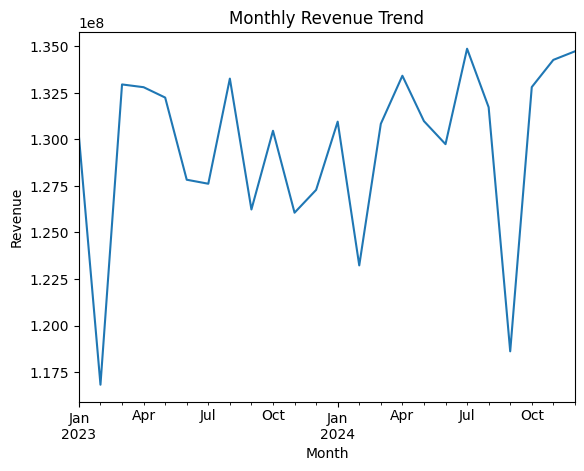

In [32]:
monthly_revenue = df.groupby('month')['revenue'].sum()

monthly_revenue.plot()
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.savefig("Images/monthly_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

#### Monthly Revenue Trend Interpretation

**What the Visualization Shows**
- The line chart displays the total monthly revenue generated from orders over the two-year period in the dataset.
- Revenue was calculated by multiplying product price by the quantity purchased for each order and aggregating the totals by month.

**Observations**
- Monthly revenue remains relatively stable throughout the period, generally ranging between **about 117 million and 135 million**.
- There are small fluctuations across months, with occasional dips and peaks.

**Interpretation**
- The fluctuations likely reflect normal variations in customer purchasing activity.
- Differences across months may be influenced by changes in order volume or the mix of products purchased.

**Business Insight**
- Monitoring monthly revenue helps businesses understand overall sales performance and identify trends in customer demand.
- Stable revenue patterns suggest consistent purchasing behavior, which is a positive indicator of business stability.

## 7. Revenue by Product Category

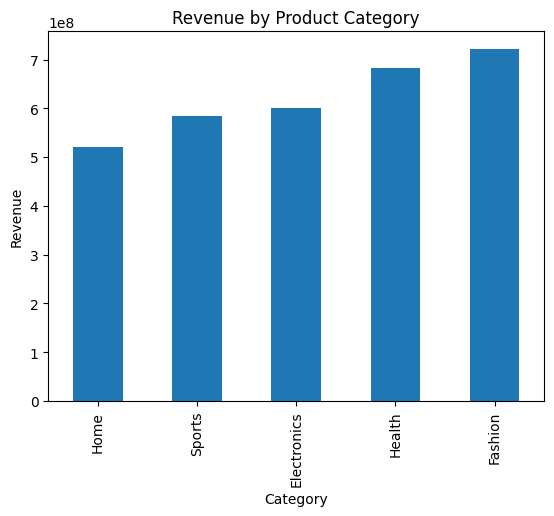

In [33]:
category_revenue = df.groupby('category')['revenue'].sum().sort_values()

category_revenue.plot(kind='bar')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.savefig("Images/category_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

#### Revenue by Product Category Interpretation

**What the Visualization Shows**
- The bar chart compares the total revenue generated by each product category in the dataset.
- Revenue was calculated by multiplying product price by the quantity purchased and aggregating the totals for each category.

**Observations**
- The **Fashion** category generates the highest revenue among all categories.
- **Health** and **Electronics** also contribute a significant share of total revenue.
- **Home** products generate the lowest revenue compared to the other categories.

**Interpretation**
- Higher revenue in categories like Fashion and Health may indicate stronger customer demand or higher-priced products within those categories.
- Lower revenue in the Home category may suggest fewer purchases or lower-priced items relative to other categories.

**Business Insight**
- Identifying top-performing product categories helps businesses prioritize inventory, marketing efforts, and product expansion.
- Focusing promotions or product development on high-performing categories could further increase overall revenue.

## 8. Customer Lifetime Value (CLV)

Customer Lifetime Value (CLV) is estimated by aggregating each customer's purchasing activity. The data is grouped by `customer_id` to calculate the total number of orders placed and the total revenue generated by each customer. Sorting the results by total spending allows us to identify the highest-value customers who contribute the most revenue to the business. This helps highlight which customers are the most engaged and valuable over the course of their interactions with the platform.

In [34]:
clv = df.groupby('customer_id').agg(
    total_orders=('order_id','count'),
    total_spent=('revenue','sum')
)

clv.sort_values('total_spent', ascending=False).head()

,total_orders,total_spent
customer_id,,
4840,24,1607872.79
4677,16,1593582.02
1774,18,1524963.18
2597,13,1512404.39
4045,22,1509698.57


## 9. Customer Age Distribution

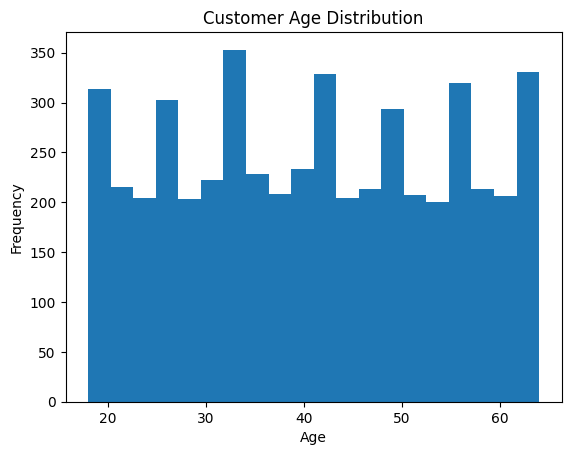

In [35]:
customers['age'].plot(kind='hist', bins=20)
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.show()

#### Customer Age Distribution Interpretation

**What the Visualization Shows**
- The histogram displays the distribution of customer ages in the dataset.
- It shows how frequently customers fall within different age ranges between 18 and 65.

**Observations**
- Customers are spread fairly evenly across the different age groups.
- There are no extreme concentrations in any single age range.
- Most age groups appear to have similar frequencies of customers.

**Interpretation**
- The relatively even distribution suggests that the platform attracts customers from a wide range of age groups.
- This indicates that purchasing activity is not heavily concentrated within a single age demographic.

**Business Insight**
- Understanding the age distribution of customers helps businesses tailor marketing strategies to different age segments.
- Since the customer base spans multiple age groups, marketing campaigns may benefit from being designed to appeal to a broad audience rather than targeting a single demographic.

## 10. Payment Method Usage

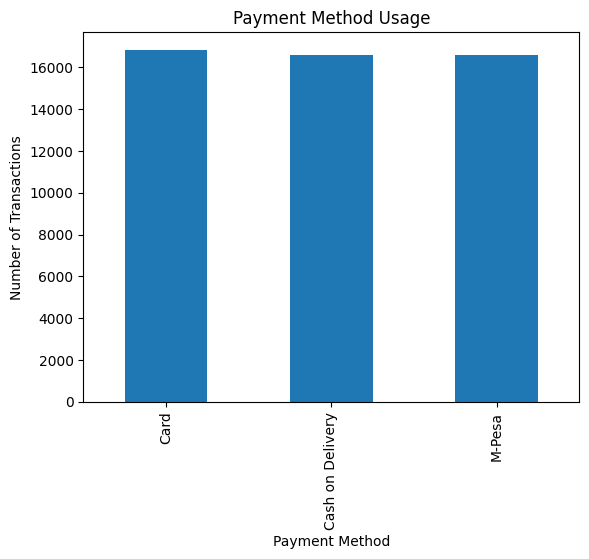

In [36]:
payment_counts = df['payment_method'].value_counts()

payment_counts.plot(kind='bar')
plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.savefig("Images/payment_methods.png", dpi=300, bbox_inches="tight")
plt.show()

#### Payment Method Usage

**What the Visualization Shows**
- The bar chart illustrates the number of transactions completed using each payment method in the dataset.
- The three payment methods represented are **Card**, **Cash on Delivery**, and **M-Pesa**.

**Observations**
- All three payment methods show a relatively similar number of transactions.
- Card payments appear slightly higher compared to the other methods.
- Cash on Delivery and M-Pesa follow closely with only small differences in transaction counts.

**Interpretation**
- The relatively balanced distribution suggests that customers use multiple payment options rather than relying heavily on a single method.
- This indicates that providing diverse payment options may help accommodate different customer preferences.

**Business Insight**
- Offering multiple payment methods can improve the overall customer experience and reduce barriers to completing purchases.
- Monitoring payment method usage can help businesses identify preferred payment options and optimize payment infrastructure accordingly.

## 11. RFM Analysis

This step performs RFM (Recency, Frequency, Monetary) analysis to better understand customer purchasing behavior. The data is grouped by `customer_id` to calculate three key metrics: 
- how recently a customer made a purchase (recency)
- how often they place orders (frequency)
- how much revenue they generate (monetary). 

These metrics help segment customers based on engagement and spending patterns, making it easier to identify loyal customers, occasional buyers, and those who may be at risk of becoming inactive.

In [37]:
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'revenue': 'sum'
})

rfm.columns = ['recency','frequency','monetary']

rfm.head()

,recency,frequency,monetary
customer_id,,,
1,63,15,1333065.07
2,23,8,469432.68
3,157,4,185220.55
4,86,14,873381.99
5,154,7,241356.23


## 12. Payment Risk Analysis

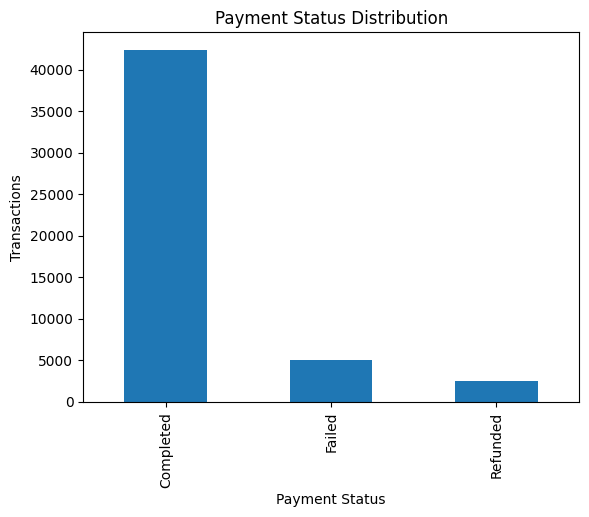

In [38]:
payment_status = df['payment_status'].value_counts()

payment_status.plot(kind='bar')
plt.title('Payment Status Distribution')
plt.xlabel('Payment Status')
plt.ylabel('Transactions')
plt.show()

#### Payment Status Distribution Interpretation

**What the Visualization Shows**
- The bar chart illustrates the distribution of transaction outcomes based on payment status.
- The three payment statuses represented are **Completed**, **Failed**, and **Refunded** transactions.

**Observations**
- The majority of transactions are **completed**, making up the largest portion of all payments.
- A smaller number of transactions are **failed**, indicating unsuccessful payment attempts.
- **Refunded transactions** represent the smallest share of the total.

**Interpretation**
- The high number of completed transactions suggests that most payments are successfully processed.
- Failed and refunded payments occur less frequently but still represent areas where payment or order issues may arise.

**Business Insight**
- Monitoring payment status helps businesses evaluate the efficiency of their payment systems.
- Understanding failed or refunded transactions can help identify potential payment processing issues and improve the overall customer checkout experience.

## 13. Key Insights

- **Revenue Trends:** Monthly revenue remained relatively stable across the observed period, with moderate fluctuations that reflect normal variations in purchasing activity.

- **Product Category Performance:** Some product categories generate higher revenue than others, indicating stronger demand or higher-value purchases within those segments.

- **Customer Demographics:** The customer base spans a broad range of age groups, suggesting that the platform appeals to a diverse audience rather than a single demographic segment.

- **Customer Value:** Customer Lifetime Value (CLV) analysis highlights that certain customers contribute significantly more revenue than others, demonstrating the importance of identifying and retaining high-value customers.

- **Customer Behavior (RFM Analysis):** Recency, Frequency, and Monetary metrics provide a clearer understanding of customer engagement, helping identify loyal customers as well as those who may become inactive over time.

- **Payment Methods:** Customers use a variety of payment options, with transactions distributed fairly evenly across the available payment methods.

- **Payment Outcomes:** Most transactions are successfully completed, while failed and refunded payments represent a smaller portion of total transactions.

## Conclusion

Overall, the analysis highlights important patterns in customer behavior, revenue generation, and payment activity that can support better decision-making in marketing, customer retention, and operational planning.